In [1]:
import os

import numpy as np
import scipy
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision

import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

from scipy.stats import binom

torch.set_printoptions(sci_mode=False)

In [2]:
%cd /home/atimans/Desktop/project_erc/erc

/home/atimans/Desktop/project_erc/erc


Experimental setup:

Introduce a probabilistic classifier and define an OOD detection problem. For every sample, the classifier's probabilities are leveraged to compute an outlier score, e.g., top-softmax probability. Introduce a threshold for binary outlier labelling: any outlier score above the threshold receives outlier label, any score below receives inlier label. Leverage risk control and calibration data to tune this threshold according to risk definition and tolerance level. Deploy model at test time online and track risk violation potential using e-process.

Experimental design:

- Pretrained probabilistic classifier
- Inlier data CIFAR-10, outlier data SVHN
- Risk definition: False Positive Rate (monotonic & in [0,1])
- Risk control: LTT

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### Using torchvision ImageNet-pretrained model (requires finetuning)

These models are only pretrained on ImageNet and require finetuning to perform optimally on e.g. CIFAR-10 or CIFAR-100. So would need a short training procedure.

In [4]:
# Define preprocessing for CIFAR-10 and SVHN
transform = transforms.Compose([
    transforms.Resize(32),  # Resize to 32x32 for CIFAR and SVHN
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize for pretrained models
])

In [45]:
cifar10_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
cifar10_loader = DataLoader(cifar10_dataset, batch_size=64, shuffle=False)

cifar100_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
cifar100_loader = DataLoader(cifar100_dataset, batch_size=64, shuffle=False)

svhn_dataset = datasets.SVHN(root='./data', split='test', download=True, transform=transform)
svhn_loader = DataLoader(svhn_dataset, batch_size=64, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified
Using downloaded and verified file: ./data/test_32x32.mat


In [80]:
print("Initial dataset shapes:")
print(f"CIFAR-10: {cifar10_dataset.data.shape}")
print(f"CIFAR-100: {cifar100_dataset.data.shape}")
print(f"SVHN: {svhn_dataset.data.shape}")

print("\nNr of classes and type:")
print(f"CIFAR-10: {len(cifar10_dataset.classes), cifar10_dataset.classes}")
print(f"CIFAR-100: {len(cifar100_dataset.classes), cifar100_dataset.classes}")
print(f"SVHN: {len(np.unique(svhn_dataset.labels)), np.unique(svhn_dataset.labels)}")

# Fully different classes
print("\nCIFAR-10 vs. CIFAR-100 overlap:", set(cifar10_dataset.classes).intersection(set(cifar100_dataset.classes)))

Initial dataset shapes:
CIFAR-10: (10000, 32, 32, 3)
CIFAR-100: (10000, 32, 32, 3)
SVHN: (26032, 3, 32, 32)

Nr of classes and type:
CIFAR-10: (10, ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])
CIFAR-100: (100, ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 's

In [12]:
from torchvision.models import resnext50_32x4d, ResNeXt50_32X4D_Weights

weights = ResNeXt50_32X4D_Weights.DEFAULT
model = resnext50_32x4d(weights=weights)
model.fc = nn.Linear(2048, 10)  # Modify for 10 classes (CIFAR-10 and SVHN)
model.to("cpu")
model.eval()

# inference transforms for model
preprocess = weights.transforms()

In [ ]:
img = torch.Tensor(cifar10_dataset.data[10]).permute(2, 0, 1)
print(img.shape)

img = preprocess(img).unsqueeze(0)
print(img.shape)

model(img).squeeze(0).softmax(0).detach().argmax(), cifar10_dataset.targets[10]

#### Using custom CIFAR-10 pretrained model

These models are taken from [this github](https://github.com/huyvnphan/PyTorch_CIFAR10) and already trained on CIFAR-10, so they are useable off the shelf.

In [4]:
from PyTorch_CIFAR10.cifar10_models.resnet import resnet50

In [6]:
model = resnet50(pretrained=True)
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [7]:
# custom inference transforms for model (see github)
mean = [0.4914, 0.4822, 0.4465]
std = [0.2471, 0.2435, 0.2616]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# load datasets, and dataloaders with transforms
cifar10_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform)
cifar10_loader = DataLoader(cifar10_dataset, batch_size=64, shuffle=False)

svhn_dataset = datasets.SVHN(root='./data', split='test', transform=transform)
svhn_loader = DataLoader(svhn_dataset, batch_size=64, shuffle=False)

In [8]:
print("Final dataset shape:")
print(f"CIFAR-10: {len(cifar10_loader.dataset), cifar10_loader.dataset.__getitem__(0)[0].shape}")
print(f"SVHN: {len(svhn_loader.dataset), svhn_loader.dataset.__getitem__(0)[0].shape}")

print("\nNr of classes and type:")
print(f"CIFAR-10: {len(cifar10_dataset.classes), cifar10_dataset.classes}")
print(f"SVHN: {len(np.unique(svhn_dataset.labels)), np.unique(svhn_dataset.labels)}")

Final dataset shape:
CIFAR-10: (10000, torch.Size([3, 32, 32]))
SVHN: (26032, torch.Size([3, 32, 32]))

Nr of classes and type:
CIFAR-10: (10, ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])
SVHN: (10, array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))


In [68]:
# inference and collect predictions
def inference(loader, model):
    print(f"{len(loader.dataset) / loader.batch_size} batches of size {loader.batch_size}.")
    all_preds, all_conf = [], []
    
    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Batch"):
            images = images.to(device)
            out = model(images).to('cpu')
            probs = nn.functional.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)
            conf = outlier_score(probs)
            
            all_preds.extend(preds.numpy())
            all_conf.extend(conf.numpy())

    return (
        np.array(all_preds, dtype=np.int32), 
        np.array(all_conf, dtype=np.float32)
    )
    
def outlier_score(probs):
    # top softmax (low top confidence = outlier)
    # score = 1 - torch.max(probs, axis=1)[0]
    
    # normalized entropy (high entropy = outlier)
    score = - torch.sum(probs * torch.log(probs + 1e-10), axis=1) / torch.log(torch.tensor(probs.shape[1]).float())
    
    return score

In [69]:
# run inference on CIFAR-10 (inlier) and SVHN (outlier)
print("Running inference on CIFAR-10 (inlier) dataset...")
cifar10_preds, cifar10_conf = inference(cifar10_loader, model)

print("Running inference on SVHN (outlier) dataset...")
svhn_preds, svhn_conf = inference(svhn_loader, model)

Running inference on CIFAR-10 (inlier) dataset...
156.25 batches of size 64.


Batch: 100%|██████████| 157/157 [00:04<00:00, 36.85it/s]


Running inference on SVHN (outlier) dataset...
406.75 batches of size 64.


Batch: 100%|██████████| 407/407 [00:10<00:00, 37.94it/s]


In [70]:
cifar10_preds[:10], cifar10_conf[:10], svhn_preds[:10], svhn_conf[:10]

(array([3, 8, 8, 0, 6, 6, 1, 6, 3, 1], dtype=int32),
 array([0.04088298, 0.04695556, 0.0521585 , 0.04220984, 0.03846278,
        0.03930046, 0.04144964, 0.03868615, 0.03988957, 0.1317654 ],
       dtype=float32),
 array([3, 3, 3, 5, 3, 3, 5, 0, 3, 5], dtype=int32),
 array([0.40998998, 0.10691661, 0.62084115, 0.5790672 , 0.68884945,
        0.4737729 , 0.12189494, 0.36792052, 0.55023474, 0.04050966],
       dtype=float32))

In [71]:
# compute basic metrics
cifar10_accuracy = (cifar10_preds == cifar10_dataset.targets).mean()
svhn_accuracy = (svhn_preds == svhn_dataset.labels).mean()
print(f"CIFAR-10 accuracy: {cifar10_accuracy:.4f}")
print(f"SVHN accuracy: {svhn_accuracy:.4f}")

print(f"CIFAR-10 mean outlier score: {cifar10_conf.mean():.4f}")
print(f"SVHN mean outlier score: {svhn_conf.mean():.4f}")

CIFAR-10 accuracy: 0.9365
SVHN accuracy: 0.1036
CIFAR-10 mean outlier score: 0.0813
SVHN mean outlier score: 0.2791


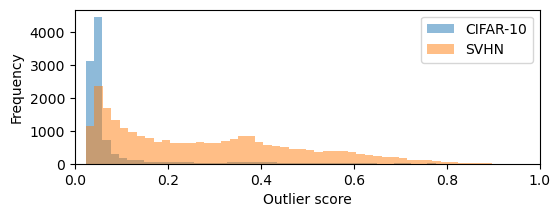

In [72]:
# plot histograms of outlier scores
plt.figure(figsize=(6, 2))
plt.hist(cifar10_conf, bins=50, alpha=0.5, label="CIFAR-10", density=False)
plt.hist(svhn_conf, bins=50, alpha=0.5, label="SVHN", density=False)
plt.xlabel("Outlier score")
plt.ylabel("Frequency")
plt.xlim(0, 1)
plt.legend()
plt.show()

#### Risk control via LTT

Learn-then-Test to determine an outlier threshold $\psi \in [0,1]$ with risk control.

In [123]:
def thresh_grid(min, max, step):
    """Create a grid of threshold values.

    Args:
        min (float): Minimum grid value.
        max (float): Maximum grid value.
        step (float): Step size between grid values.

    Returns:
        torch.Tensor: Grid of threshold values.
    """
    threshs = torch.arange(max, min, -step, dtype=torch.float)
    # every thresh has at most the same number of decimal points as step
    threshs = torch.round(threshs / step) * step
    return threshs


def hb_p_value(risk, n, eps, binary_loss: bool):
    """Compute the p-value of the Hoeffding-Bentkus bound. If binary loss, use the binomial CDF directly.
    Adapted from https://github.com/aangelopoulos/ltt/blob/main/core/bounds.py

    Args:
        risk: Computed risk estimate.
        n: Number of calibration samples.
        eps: Tolerated risk level.

    Returns:
        p-value.
    """
    if binary_loss:
        p_value = binom.cdf(np.ceil(n * risk), n, eps)
    else:
        bentkus_p_value = np.e * binom.cdf(np.ceil(n * risk), n, eps)
        a, b = min(risk, eps), eps
        h1 = a * np.log(a / b) + (1 - a) * np.log((1 - a) / (1 - b))
        hoeffding_p_value = np.exp(-n * h1)
        p_value = min(bentkus_p_value, hoeffding_p_value)

    assert 0 - 1e-4 <= p_value <= 1 + 1e-4, "p-value must be in [0, 1]: {}".format(p_value)
    return p_value


def get_ltt_thresh(losses, eps, delta, binary_loss=False, loss_B=1.0):
    # losses: (N_thresh, N_cal)
    # select thresh closest s.t. LTT p-value is controlled on calibration data
    
    # Note that LTT requires losses in [0, 1], thus we first need to rescale the losses if loss_B > 1
    losses = torch.max(torch.zeros_like(losses), (1 / loss_B) * losses)
    
    N_thresh, N_cal = losses.shape
    risk = losses.mean(dim=1) # (N_thresh,)
    
    pval = torch.zeros((N_thresh,))
    for i in range(N_thresh):
        pval[i] = torch.tensor([hb_p_value(risk[i].item(), N_cal, eps, binary_loss)])
    
    thresh_ids = (pval <= delta).nonzero(as_tuple=True)[0]
    if thresh_ids.shape[0] == 0: # no accept
        thresh_id = torch.tensor([0])
        thresh_ids = torch.tensor([0])
    else:
        thresh_id = thresh_ids[-1] # smallest thresh (from below)
    return thresh_id, thresh_ids, pval


In [56]:
# Define a grid of outlier threshold candidates in the range [0, 1]
thresh_cand = thresh_grid(0, 1, 0.01)
thresh_cand

tensor([1.0000, 0.9900, 0.9800, 0.9700, 0.9600, 0.9500, 0.9400, 0.9300, 0.9200,
        0.9100, 0.9000, 0.8900, 0.8800, 0.8700, 0.8600, 0.8500, 0.8400, 0.8300,
        0.8200, 0.8100, 0.8000, 0.7900, 0.7800, 0.7700, 0.7600, 0.7500, 0.7400,
        0.7300, 0.7200, 0.7100, 0.7000, 0.6900, 0.6800, 0.6700, 0.6600, 0.6500,
        0.6400, 0.6300, 0.6200, 0.6100, 0.6000, 0.5900, 0.5800, 0.5700, 0.5600,
        0.5500, 0.5400, 0.5300, 0.5200, 0.5100, 0.5000, 0.4900, 0.4800, 0.4700,
        0.4600, 0.4500, 0.4400, 0.4300, 0.4200, 0.4100, 0.4000, 0.3900, 0.3800,
        0.3700, 0.3600, 0.3500, 0.3400, 0.3300, 0.3200, 0.3100, 0.3000, 0.2900,
        0.2800, 0.2700, 0.2600, 0.2500, 0.2400, 0.2300, 0.2200, 0.2100, 0.2000,
        0.1900, 0.1800, 0.1700, 0.1600, 0.1500, 0.1400, 0.1300, 0.1200, 0.1100,
        0.1000, 0.0900, 0.0800, 0.0700, 0.0600, 0.0500, 0.0400, 0.0300, 0.0200,
        0.0100])

In [87]:
# Select a random subset of fixed size from the inlier data as calibration set
n_cal = int(0.5 * len(cifar10_preds))
cal_idx = torch.randperm(len(cifar10_preds))[:n_cal]
print(f"Using {n_cal} calibration samples.")
print(cal_idx[:10])

Using 5000 calibration samples.
tensor([4085, 7252, 8630, 8159, 3186, 6282, 3714, 7131, 5708, 7633])


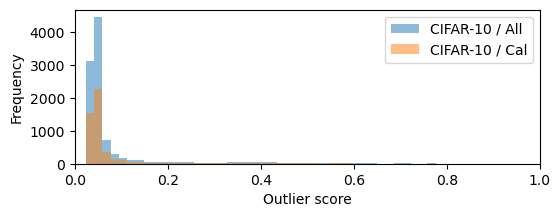

In [159]:
# assert that the calibration set is representative
plt.figure(figsize=(6, 2))
plt.hist(cifar10_conf, bins=50, alpha=0.5, label="CIFAR-10 / All", density=False)
plt.hist(cifar10_conf[cal_idx], bins=50, alpha=0.5, label="CIFAR-10 / Cal", density=False)
plt.xlabel("Outlier score")
plt.ylabel("Frequency")
plt.xlim(0, 1)
plt.legend()
plt.show()

Consider the risk as false positive rate. Then $FPR(\mathcal{D}_{cal}) = \frac{\#{FP}}{N_{cal}} \in [0,1]$, and a calibration sample $i$ is classified as $FP$ if its outlier score $out_i > \psi$ since all calibration samples are known to be in-distribution.

In [177]:
# collect losses in a grid of size (N_thresh, N_cal)

def loss(thresh, conf):
    return (conf > thresh).float()

def get_losses(thresh_cand, conf):
    n_thresh, n_cal = len(thresh_cand), len(conf)
    losses = torch.zeros((n_thresh, n_cal))
    
    for i, thresh in enumerate(thresh_cand):
        losses[i] = loss(thresh, conf)
    
    return losses

In [180]:
eps = 0.05 # risk level
delta = 0.1 # significance level

losses = get_losses(thresh_cand, torch.tensor(cifar10_conf[cal_idx]))
risk = losses.mean(dim=1)
thresh_id, thresh_ids, pval = get_ltt_thresh(losses, eps, delta, binary_loss=True)

print(f"Selected threshold: {thresh_cand[thresh_id]}, p-value: {pval[thresh_id]}, risk: {risk[thresh_id]}")

Selected threshold: 0.35999998450279236, p-value: 0.026079583913087845, risk: 0.04399999976158142


In [193]:
# visualize risk control decision
def plot_thresh_risk_pval(thresh, risk, pval, rc_lam, epsilon, delta, save_dir=None, save_name=None):
    """
    Plot the risk and p-value as a function of thresh.
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 2.5))
    ax1.plot(thresh, risk, color="black")
    ax1.set_xlim(max(thresh) + 1e-2, 0 - 1e-3)
    ax1.set_xlabel(r"Threshold parameter $\psi$")
    ax1.set_ylabel("Risk")
    ax1.axhline(y=epsilon, color="red", ls=":", label=r"Risk level $\epsilon$", lw=2)
    ax1.axvline(
        x=rc_lam, color="green", ls=":", label=r"Risk controlling $\hat{\psi}$", lw=2
    )
    ax1.legend()

    ax2.plot(thresh, pval, color="black")
    ax2.set_xlim(max(thresh) + 1e-2, 0 - 1e-3)
    ax2.set_xlabel(r"Threshold parameter $\psi$")
    ax2.set_ylabel("P-value")
    ax2.axhline(y=epsilon, color="red", ls=":", label=r"Risk level $\epsilon$", lw=2)
    ax2.axvline(
        x=rc_lam, color="green", ls=":", label=r"Risk controlling $\hat{\psi}$", lw=2
    )
    ax2.legend()

    fig.suptitle(rf"Target guarantee: $\epsilon={epsilon}$, $\delta={delta}$")
    # fname = "thresh_risk_pval.png" if save_name is None else save_name
    # plt.savefig(
    #     os.path.join(save_dir, fname),
    #     bbox_inches="tight",
    # )
    plt.show()


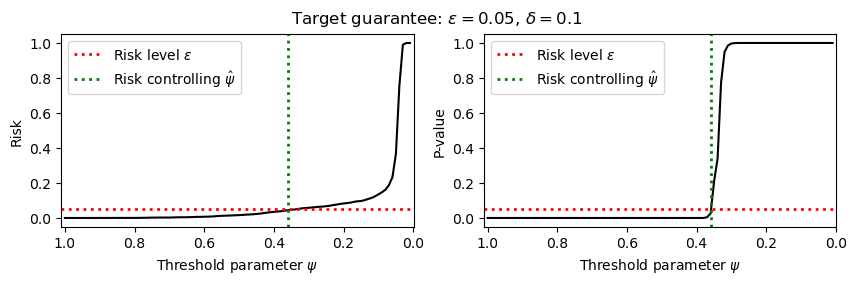

In [194]:
plot_thresh_risk_pval(thresh_cand, risk, pval, thresh_cand[thresh_id], eps, delta)

In [210]:
# Check the selected threshold on the test set
test_losses = get_losses(thresh_cand, torch.tensor(cifar10_conf[~cal_idx]))
test_risk = test_losses.mean(dim=1)

print(f"Test risk: {test_risk[thresh_id]}")

Test risk: 0.04439999908208847


In [209]:
def plot_test_risk(risk, losses, epsilon, delta, save_dir=None, save_name=None):
    """
    Plot the test risk and loss statistics.
    """
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    ax.hist(
        losses,
        bins=30,
        density=True,
        color="lightgray",
        edgecolor="black",
        linewidth=1,
        alpha=0.8,
    )
    ax.set_ylabel("Density")
    ax.set_xlabel("Test losses")
    ax.set_xlim(-0.03, 1.03)
    ax.axvline(x=epsilon, color="red", ls="-", label=r"Risk level $\epsilon$", lw=2)
    ax.axvline(
        x=risk,
        color="green",
        ls="-",
        label=f"Test risk: {risk:.3f}",
        lw=2,
    )
    ax.legend()
    fig.suptitle("Risk control on test data")
    # fname = "test_risk.png" if save_name is None else save_name
    # plt.savefig(
    #     os.path.join(save_dir, fname),
    #     bbox_inches="tight",
    # )
    plt.show()

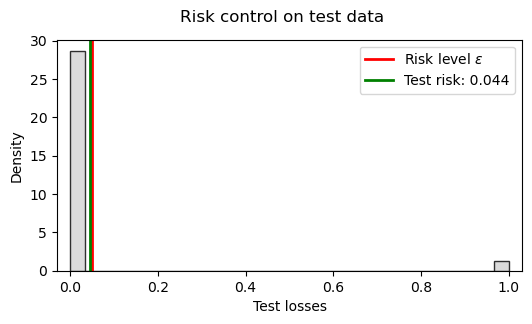

In [211]:
plot_test_risk(test_risk[thresh_id], test_losses[thresh_id], eps, delta)